In [1]:
import sys
import os

current_dir = os.getcwd()
module_path = os.path.join(current_dir, '..', 'external', 'SOTA-py', 'src')
module_path = os.path.normpath(module_path)

if module_path not in sys.path:
    sys.path.append(module_path)

new_folder_path = os.path.normpath(os.path.join(current_dir, '..', 'external', 'SOTA-py', 'graph'))

if new_folder_path not in sys.path:
    sys.path.append(new_folder_path)

from stochastic_graph import StochasticGraph
from preprocessing import bfReach, detReach, bfArcFlags, detArcFlags
from SOTA import StandardSOTASolver, SingleIterationSOTASolver
from deterministic_algorithms import Dijkstra
from utilities import Utils
from Grid_network_and_Gamma_distribution import Matrix

src_folder_path = os.path.normpath(os.path.join(current_dir, '..', 'src'))

if src_folder_path not in sys.path:
    sys.path.append(src_folder_path)

from R2L_train import GridNet, afGridNet, reachGridNet
from R2L_test import Test
from R2L_utilities import R2LTestFunctions

%matplotlib inline

%load_ext autoreload
%autoreload 2

======== STANDARD R2L =========

Object loaded from ./../instances/graphs/5x5-1.pkl


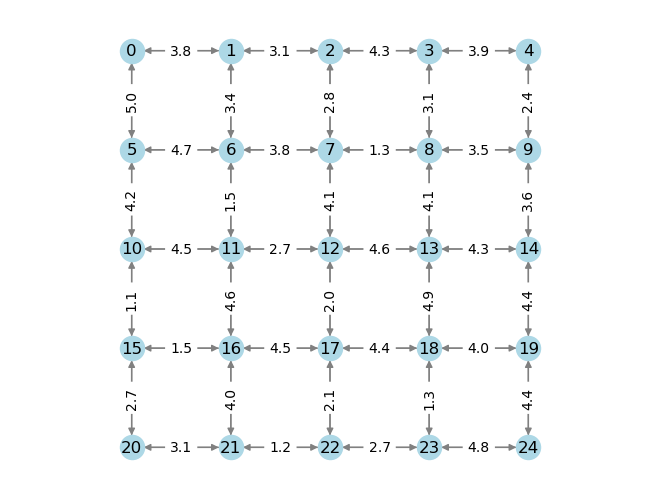

FileNotFoundError: [Errno 2] No such file or directory: './../instances/trained/grid_5x5_20000k500k-gn.pkl'

In [2]:
path_graph = "./../instances/graphs/5x5-1.pkl"

path_gn = "./../instances/trained/grid_5x5_20000k500k-gn.pkl"
path_af = "./../instances/trained/grid_5x5_20000k500k-af.pkl"
path_rh = "./../instances/trained/grid_5x5_20000k500k-rh.pkl"

R2LTestFunctions.gn_af_rh_path_comparison(path_graph, path_gn, path_af, path_rh, start_node = 10, 
                                          remaining_reward=25, dont_print=True, print_graph_path=True, print_graph_pruned=True)

Object loaded from ./../instances/graphs/5x5-1.pkl
Reach values computeds...
Pruning nodes...Reach values computed and graph pruned (8 nodes) in 0.0123s
data loaded correctly.
SOTA path: [0, 5, 6, 11, 12, 17, 22, 23, 24]


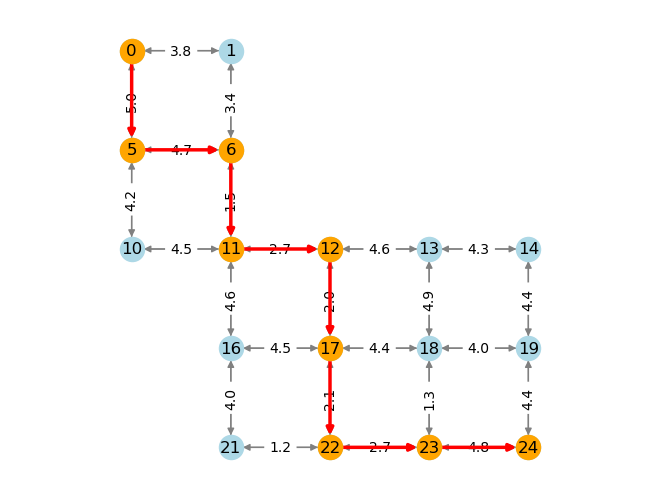

In [47]:
path_graph = "./../instances/graphs/5x5-1.pkl"
path_rh = "./../instances/trained/grid_5x5_test-rh.pkl"

graph = Utils.load_object(path_graph)
grid = reachGridNet(graph.get_adjacency_matrix(), graph.get_variance_matrix(), episode_number=500000, episode_lissage=50000)


test = Test(grid)
path = test.run(path_rh, start_node=0, remaining_reward=25, dont_print=True)

grid.get_graph().print_graph(path=path)



#R2LTestFunctions.path_run(path_graph, path_rh, grid_type="reach", start_node=0, remaining_reward = 25, dont_print=True,print_graph_path=True)

In [ ]:
path_graph = "./../instances/graphs/5x5-1.pkl"

R2LTestFunctions.train_run(path_graph, "reach", 0, 24, 100000, 25000, "./../instances/trained/grid_5x5_undefined.pkl")

Object loaded from ./../instances/graphs/5x5-1.pkl
Reach values computeds...
Pruning nodes...Reach values computed and graph pruned (8 nodes) in 0.0134s
Episode =  10000 ----------  Error norm sup =  1 ----------  Error norm 1 =  1
step_nbr =  1.7086044830079536
Episode =  20000 ----------  Error norm sup =  1.1358664450276309e-08 ----------  Error norm 1 =  1.0251156441502602e-10
step_nbr =  2.3686131386861313
Episode =  30000 ----------  Error norm sup =  0.013975610370381454 ----------  Error norm 1 =  0.00031539655729519357
step_nbr =  2.411873840445269
Episode =  40000 ----------  Error norm sup =  0.015413524629153737 ----------  Error norm 1 =  0.00034096514681039624
step_nbr =  2.379840196681008
Episode =  50000 ----------  Error norm sup =  0.01843001483863208 ----------  Error norm 1 =  0.0003436780333367793
step_nbr =  2.384661473936489
Episode =  60000 ----------  Error norm sup =  0.016360250361127253 ----------  Error norm 1 =  0.00034437100338459187
step_nbr =  2.4633375

In [6]:
path_graph = "./../instances/graphs/5x5-1.pkl"
path_gn = "./../instances/trained/grid_5x5-1_20000k200k-gn.pkl"
path_af = "./../instances/trained/grid_5x5-1_20000k200k-af.pkl"
path_rh = "./../instances/trained/grid_5x5-1_20000k200k-rh.pkl"

R2LTestFunctions.train_general_comparison(path_graph, 0, 24, 20000000, 200000, path_gn, path_af, path_rh)

======== STANDARD R2L =========

Object loaded from ./../instances/graphs/5x5-1.pkl
Episode =  200000 ----------  Error norm sup =  1 ----------  Error norm 1 =  1
step_nbr =  2.982604131518764
Episode =  400000 ----------  Error norm sup =  8.327404657622189e-05 ----------  Error norm 1 =  1.0751997416323667e-06
step_nbr =  3.049102060303353
Episode =  600000 ----------  Error norm sup =  0.20681761167625612 ----------  Error norm 1 =  0.0059082292781137595
step_nbr =  3.037126236614917
Episode =  800000 ----------  Error norm sup =  0.25178686754169194 ----------  Error norm 1 =  0.006205211962998461
step_nbr =  3.060467665327
Episode =  1000000 ----------  Error norm sup =  0.3438803626620025 ----------  Error norm 1 =  0.006370176243558099
step_nbr =  3.098045626271433
Episode =  1200000 ----------  Error norm sup =  0.16144337606411582 ----------  Error norm 1 =  0.006612730847427239
step_nbr =  3.036775928483175
Episode =  1400000 ----------  Error norm sup =  0.3762667411957704 

KeyboardInterrupt: 

In [7]:
path_graph = "./../instances/graphs/5x5-1.pkl"
path_rh = "./../instances/trained/grid_5x5-1_20000k200k-rh.pkl"

R2LTestFunctions.train_run(path_graph, "reach", 0, 24, 20000000, 200000, path_rh)

Object loaded from ./../instances/graphs/5x5-1.pkl
Reach values computeds...
Pruning nodes...Reach values computed and graph pruned (8 nodes) in 0.0189s
Episode =  200000 ----------  Error norm sup =  1 ----------  Error norm 1 =  1
step_nbr =  2.302204614872834
Episode =  400000 ----------  Error norm sup =  0.00010575989638479286 ----------  Error norm 1 =  1.3942154967801152e-06
step_nbr =  2.3289438080634977
Episode =  600000 ----------  Error norm sup =  0.21438557088619023 ----------  Error norm 1 =  0.006683285467584941
step_nbr =  2.3766307600239376
Episode =  800000 ----------  Error norm sup =  0.16253522489305078 ----------  Error norm 1 =  0.006895824581675442
step_nbr =  2.368307258040299
Episode =  1000000 ----------  Error norm sup =  0.1270959677320544 ----------  Error norm 1 =  0.007186648537753129
step_nbr =  2.3681064115976684
Episode =  1200000 ----------  Error norm sup =  0.12258689990136398 ----------  Error norm 1 =  0.007349810905418041
step_nbr =  2.381685046

7692.272778272629

======== STANDARD R2L =========

Object loaded from ./../instances/graphs/5x5-1.pkl
data loaded correctly.
SOTA path: [10, 11, 16, 17, 18, 23, 24]
Probability Q-value: 0.39243517899306607


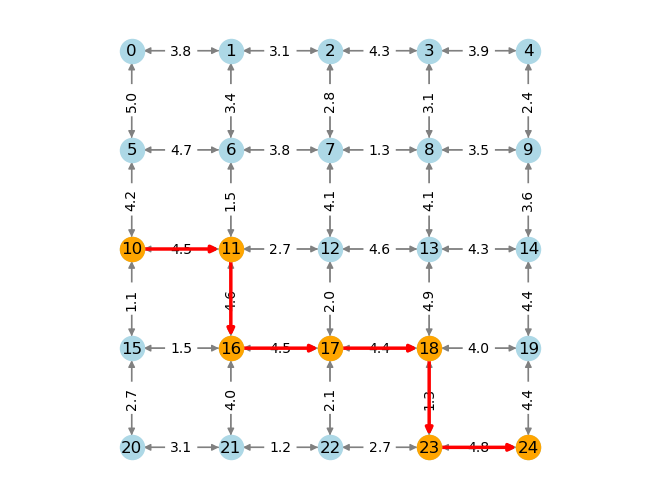


======== ARC-FLAGS R2L ========

Object loaded from ./../instances/graphs/5x5-1.pkl
Partitioning of the graph in 4 regions executed in 0.0020 seconds!
Arcflags computed!...
[ArcFlags] Pruned 9 edges for destination 24 (region 0).
Arcflags computed and graph pruned in 0.0080s
data loaded correctly.
SOTA path: [10, 11, 16, 17, 22, 23, 24]
Probability Q-value: 0.32582126081028634


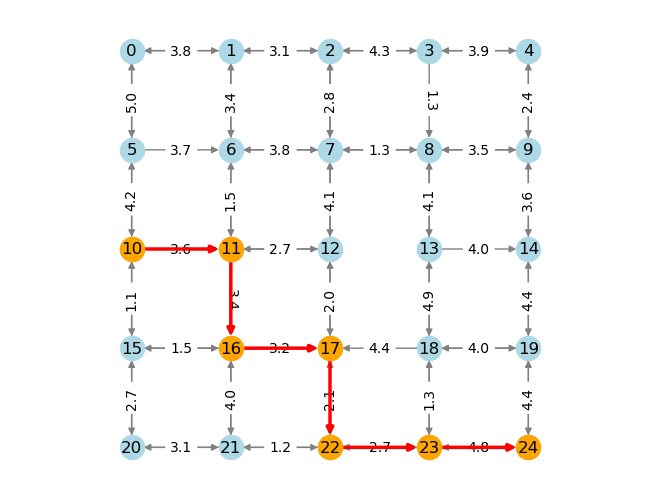


======== REACH R2L ========

Object loaded from ./../instances/graphs/5x5-1.pkl
Reach values computeds...
Pruning nodes...Reach values computed and graph pruned (8 nodes) in 0.0120s
data loaded correctly.
SOTA path: [10, 11, 16, 17, 18, 19, 24]
Probability Q-value: 0.5865419805072815


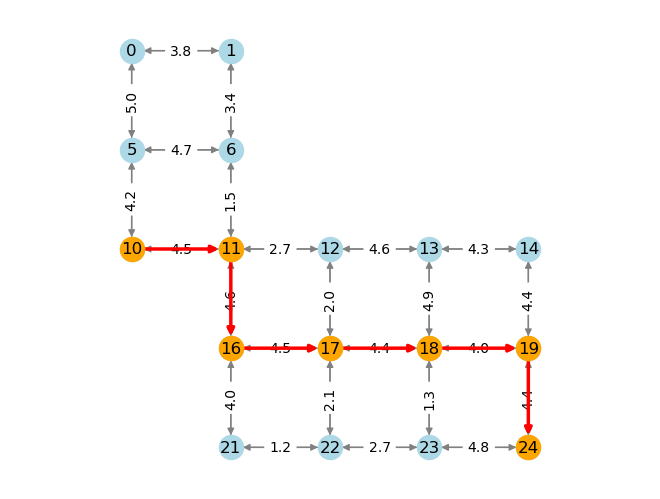

In [13]:
path_graph = "./../instances/graphs/5x5-1.pkl"
path_gn = "./../instances/trained/grid_5x5-1_20000k200k-gn.pkl"
path_af = "./../instances/trained/grid_5x5-1_20000k200k-af.pkl"
path_rh = "./../instances/trained/grid_5x5-1_20000k200k-rh.pkl"

R2LTestFunctions.gn_af_rh_path_comparison(path_graph, path_gn, path_af, path_rh, 
                                          10, 29, dont_print=True, print_graph_path=True)